In [8]:
import os
import zipfile
from google.colab import files
ZIP_PATH = "/content/archive.zip"
if os.path.exists(ZIP_PATH):
    print("Existing ZIP file found:")
    print(ZIP_PATH)
else:
    print("No ZIP file found. Please upload the dataset ZIP file.")
    uploaded = files.upload()
    ZIP_PATH = "/content/" + next(iter(uploaded))
    print("\nUploaded file:")
    print(ZIP_PATH)
if not zipfile.is_zipfile(ZIP_PATH):
    raise ValueError("The selected file is not a valid ZIP file.")
print("\nZIP file verified successfully.")

Existing ZIP file found:
/content/archive.zip

ZIP file verified successfully.


In [9]:
import os
import zipfile
EXTRACT_DIR = "/content/oral_cancer_dataset"
if os.path.exists(EXTRACT_DIR):
    import shutil
    shutil.rmtree(EXTRACT_DIR)
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)
print("Dataset extracted successfully.")
print("Location:", EXTRACT_DIR)

Dataset extracted successfully.
Location: /content/oral_cancer_dataset


In [10]:
for root, dirs, files_list in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files_list[:5]:
        print(f"{indent}    {file}")

oral_cancer_dataset/
    OralCancer/
        non-cancer/
            _tongue.jpg
            388x210-White_Bumps_on_Lips.jpg
            WP_20141029_18_42_38_Pro2.jpg
            20200314_1117132.jpg
            Normal-tongue-out--1296x728-gallery_slide1.jpg
        cancer/
            oral-cancer-screening.jpg
            ds01089_im00213_c7_lipcancerpicturethu_jpg.jpg
            dataset_mouth-cancer-symptoms-1.jpg
            pract_oral_cancer.jpg
            18b79305-949e-4ed8-849c-ec5d5a794752.jpg


In [ ]:
import os
import pandas as pd
DATASET_DIR = "/content/oral_cancer_dataset/OralCancer"
data = []
for label in ["cancer", "non-cancer"]:
    class_dir = os.path.join(DATASET_DIR, label)
    for filename in os.listdir(class_dir):
        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")
        ):
            data.append({
                "image_path": os.path.join(class_dir, filename),
                "label": label,
                "filename": filename
            })
df = pd.DataFrame(data)
print("Dataset loaded successfully.")
print("Total images:", len(df))
df.head()

In [11]:
print("=" * 50)
print("DATASET DESCRIPTION")
print("=" * 50)

print("Total samples:", len(df))
print("Target variable:", "label")
print("Number of classes:", df["label"].nunique())

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nDataset columns:")
print(df.columns.tolist())

DATASET DESCRIPTION
Total samples: 131
Target variable: label
Number of classes: 2

Class distribution:
label
cancer        87
non-cancer    44
Name: count, dtype: int64

Dataset columns:
['image_path', 'filename', 'label']


In [12]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
image_path    0
filename      0
label         0
dtype: int64

Duplicate rows: 0


In [13]:
from PIL import Image
corrupt_images = []
for path in df["image_path"]:
    try:
        with Image.open(path) as img:
            img.verify()
    except:
        corrupt_images.append(path)
print("Total images:", len(df))
print("Corrupt/unreadable images:", len(corrupt_images))

Total images: 131
Corrupt/unreadable images: 0


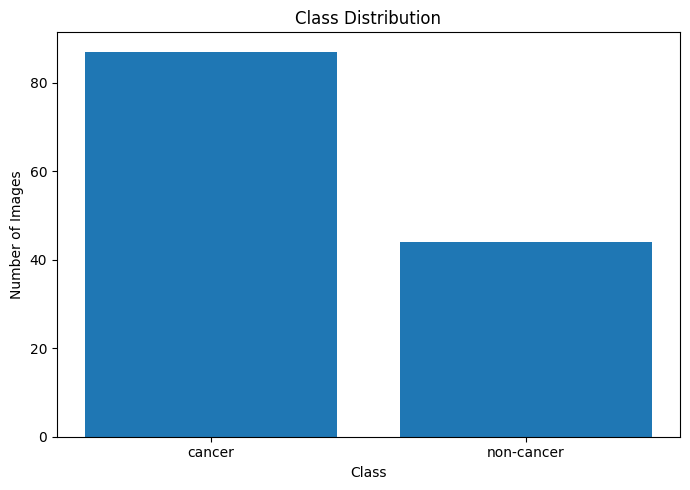

In [14]:
import matplotlib.pyplot as plt
counts = df["label"].value_counts()
plt.figure(figsize=(7, 5))
plt.bar(counts.index, counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

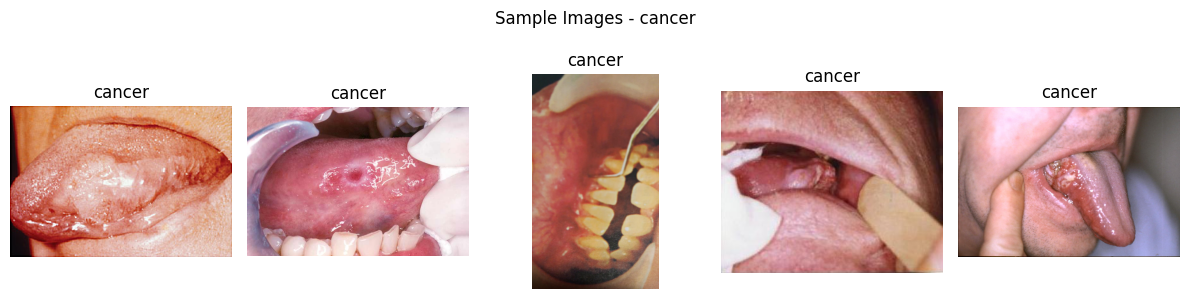

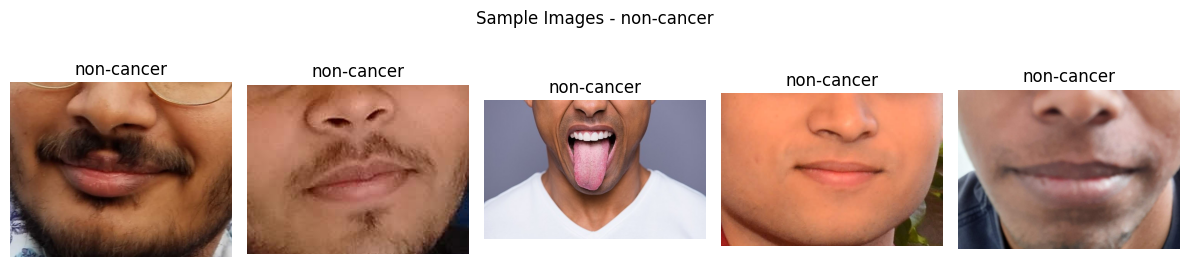

In [15]:
import random
for label in ["cancer", "non-cancer"]:
    samples = df[df["label"] == label].sample(min(5, len(df[df["label"] == label])),random_state=42)
    plt.figure(figsize=(12, 3))
    for i, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        plt.subplot(1, len(samples), i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(label)
    plt.suptitle(f"Sample Images - {label}")
    plt.tight_layout()
    plt.show()

In [16]:
image_stats = []
for _, row in df.iterrows():
    try:
        img = Image.open(row["image_path"]).convert("L")
        image_stats.append({
            "label": row["label"],
            "width": img.width,
            "height": img.height,
            "brightness": float(
                __import__("numpy").array(img).mean())})
    except:
        pass
stats_df = pd.DataFrame(image_stats)
stats_df.groupby("label")[["width", "height", "brightness"]].mean()

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


,width,height,brightness
label,,,
cancer,769.091954,601.436782,130.674278
non-cancer,855.090909,655.545455,126.380658


<Figure size 800x500 with 0 Axes>

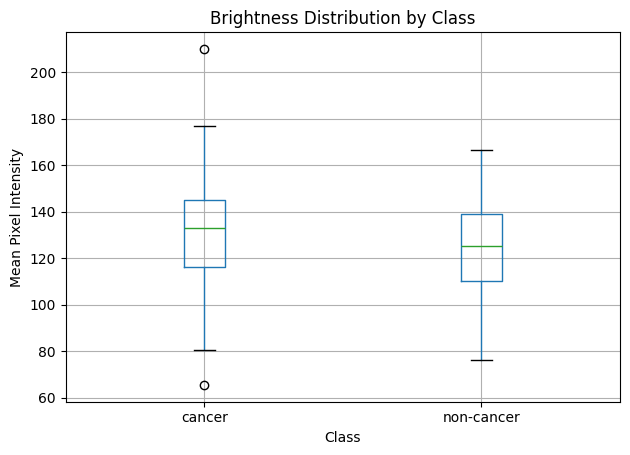

In [17]:
plt.figure(figsize=(8, 5))
stats_df.boxplot(column="brightness",by="label")
plt.title("Brightness Distribution by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Mean Pixel Intensity")
plt.tight_layout()
plt.show()

In [18]:
correlation = stats_df[["width", "height", "brightness"]].corr()
print(correlation)

               width    height  brightness
width       1.000000  0.884379    0.060026
height      0.884379  1.000000    0.003399
brightness  0.060026  0.003399    1.000000


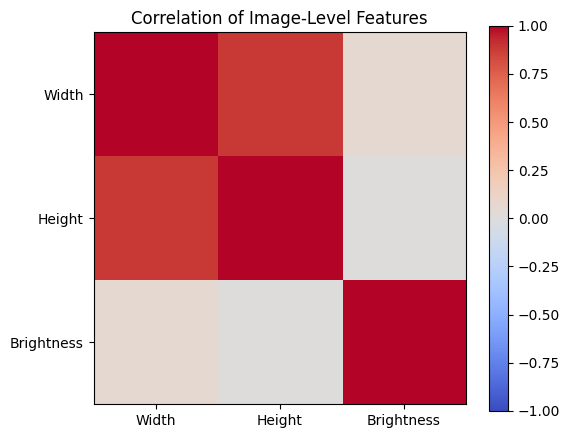

In [19]:
plt.figure(figsize=(6, 5))
plt.imshow(correlation,cmap="coolwarm",vmin=-1,vmax=1)
plt.colorbar()
plt.xticks(range(3),["Width", "Height", "Brightness"])
plt.yticks(range(3),["Width", "Height", "Brightness"])
plt.title("Correlation of Image-Level Features")
plt.show()

In [20]:
import numpy as np
from skimage.feature import hog
IMAGE_SIZE = (128, 128)
def extract_hog(image_path):
    img = Image.open(image_path).convert("L")
    img = img.resize(IMAGE_SIZE)
    features = hog(np.array(img),orientations=9,pixels_per_cell=(8, 8),cells_per_block=(2, 2),block_norm="L2-Hys")
    return features

In [21]:
X = []
y = []
for _, row in df.iterrows():
    try:
        features = extract_hog(row["image_path"])
        X.append(features)
        y.append(row["label"])
    except:
        pass
X = np.array(X)
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", encoder.classes_)

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Feature matrix shape: (131, 8100)
Target shape: (131,)
Classes: ['cancer' 'non-cancer']


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 104
Testing samples: 27


In [23]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000,random_state=42)
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


In [24]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report)
y_pred = model.predict(X_test)
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, average="weighted"), 4))
print("Recall   :", round(recall_score(y_test, y_pred, average="weighted"), 4))
print("F1 Score :", round(f1_score(y_test, y_pred, average="weighted"), 4))
print("\nClassification Report:")
print(classification_report(y_test,y_pred,target_names=encoder.classes_))

Accuracy : 0.8148
Precision: 0.8175
Recall   : 0.8148
F1 Score : 0.8034

Classification Report:
              precision    recall  f1-score   support

      cancer       0.81      0.94      0.87        18
  non-cancer       0.83      0.56      0.67         9

    accuracy                           0.81        27
   macro avg       0.82      0.75      0.77        27
weighted avg       0.82      0.81      0.80        27



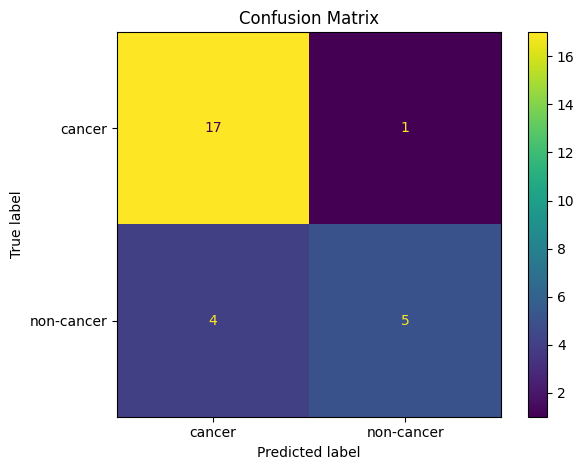

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=encoder.classes_)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Saving Screenshot 2026-09-02 at 17.40.16.png to Screenshot 2026-09-02 at 17.40.16 (4).png
Prediction: cancer
Model confidence: 94.59 %


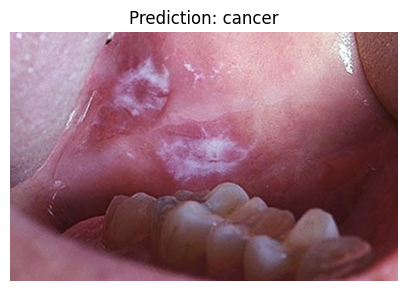

In [26]:
from google.colab import files
uploaded = files.upload()
image_path = next(iter(uploaded))
features = extract_hog(image_path)
features = features.reshape(1, -1)
prediction = model.predict(features)[0]
probability = model.predict_proba(features).max()
predicted_class = encoder.inverse_transform([prediction])[0]
print("Prediction:", predicted_class)
print("Model confidence:", round(probability * 100, 2), "%")
plt.figure(figsize=(5, 5))
plt.imshow(Image.open(image_path).convert("RGB"))
plt.axis("off")
plt.title(f"Prediction: {predicted_class}")
plt.show()

<IPython.core.display.Javascript object>

Image captured successfully!


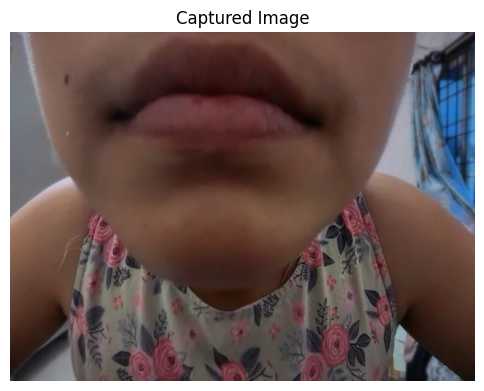

ORAL CANCER SCREENING RESULT
Prediction : cancer
Confidence : 78.93 %


In [32]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from PIL import Image
import matplotlib.pyplot as plt


def take_photo(filename="camera_image.jpg", quality=0.8):

    js = Javascript('''
    async function takePhoto(quality) {

        const video = document.createElement('video');

        video.style.width = '500px';
        video.style.display = 'block';

        const button = document.createElement('button');

        button.textContent = '📷 Capture Image';
        button.style.fontSize = '18px';
        button.style.padding = '10px';

        document.body.appendChild(video);
        document.body.appendChild(button);

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        video.srcObject = stream;

        await video.play();

        await new Promise(resolve => {
            button.onclick = resolve;
        });

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(
            video,
            0,
            0
        );

        stream.getTracks().forEach(track => track.stop());

        video.remove();
        button.remove();

        return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)

    data = eval_js("takePhoto({})".format(quality))

    binary = b64decode(data.split(',')[1])

    with open(filename, "wb") as f:
        f.write(binary)

    return filename


# -----------------------------------
# CAMERA
# -----------------------------------

try:

    image_path = take_photo()

    print("Image captured successfully!")

    img = Image.open(image_path)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Captured Image")
    plt.show()


    # -----------------------------------
    # MODEL PREDICTION
    # -----------------------------------

    features = extract_hog(image_path)
    features = features.reshape(1, -1)

    prediction = model.predict(features)[0]

    probability = model.predict_proba(features).max()

    predicted_class = encoder.inverse_transform(
        [prediction]
    )[0]

    print("=" * 40)
    print("ORAL CANCER SCREENING RESULT")
    print("=" * 40)

    print("Prediction :", predicted_class)
    print("Confidence :", round(probability * 100, 2), "%")


except Exception as e:

    print("Camera access was not available.")
    print()
    print("Please allow camera access for Google Colab")
    print("or use the image-upload option instead.")
    print()
    print("Error:", e)